# US Firm Characteristics: Label Engineering

Every model in this case study is trained to predict the label defined here, so an error
in it is silent where it is made and reaches every metric and every backtest after it.
This notebook fixes what the label is and when it is known, proves that the panel really
is aligned the way the provider documents, measures how much independent information the
rows carry, establishes the floor a feature has to clear, and writes the files stage 03
reads.

## Learning objectives

- Read the alignment of a pre-built research panel out of the data instead of trusting
  the accompanying prose, and say which date a label resolves on
- Assert that a label exists exactly where its outcome was observed, rather than counting
  the rows that carry one
- Separate a threshold that is point-in-time by construction from one that has to be
  fitted inside a training fold
- Price the overlap between consecutive labels, and see what an effective row count says
  when there is none
- Establish the floor a feature has to clear, under a standard error computed on the
  series of monthly decisions rather than on the pooled firm-months

## Book reference, prerequisites and artifacts

Chapter 7, Section 7.2. Reads the Chen-Pelger-Zhu panel through
`load_firm_characteristics()`, whose breadth and cost feasibility
[`01_feasibility_analysis`](01_feasibility_analysis.ipynb) establishes, and
`config/setup.yaml`, which declares the label set, the buffer and the holdout boundary.
Writes `labels/prices.parquet` for the backtest loader, one parquet per declared label,
a `.digest.json` sidecar beside each of them, and `config/cv_config.json`, which
`04_evaluation.py` reads for its fold boundaries.

In [1]:
"""US Firm Characteristics: Label Engineering."""

import json
import warnings
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from matplotlib.ticker import PercentFormatter
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.label_diagnostics import effective_sample_size, panel_autocorrelation
from data import load_firm_characteristics
from utils.artifact_specs import resolve_label_buffer, resolve_label_horizon
from utils.cv_splits import generate_cv_splits
from utils.paths import display_path, get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

warnings.filterwarnings("ignore")

CASE_STUDY_ID = "us_firm_characteristics"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
LABELS_DIR = CASE_DIR / "labels"

The two parameters bound the study window and are both read below. The release starts two
decades earlier than the window used here; the folds `setup.yaml` declares need a decade
of training before the first validation year, and this window leaves room for that
without reaching back into a period whose cross-section is half its later size.

In [2]:
START_DATE = "1990-01-01"
END_DATE = "2016-12-31"

## Configuration

Everything that defines a label is declared in `config/setup.yaml` and bound here. A
horizon or a boundary typed into a cell is a second copy of a value the rest of the
pipeline reads from the file, and the two drift apart the first time either is edited.

`resolve_label_horizon` prefers an explicit `labels.horizons` entry and falls back to the
cross-validation buffer. The two fields are separate, because the gap that keeps folds
independent need not equal the horizon an outcome resolves over; here they coincide, and
both are declared in months.

In [3]:
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_NAMES = [PRIMARY_LABEL, *SETUP["labels"].get("variants", [])]
WINSORIZED_LABEL, CLASS_LABEL = LABEL_NAMES[1], LABEL_NAMES[2]
HORIZON = resolve_label_horizon(CASE_STUDY_ID, PRIMARY_LABEL, SETUP)
LABEL_BUFFER = resolve_label_buffer(CASE_STUDY_ID, PRIMARY_LABEL, SETUP)
HORIZON_MONTHS = int(HORIZON.rstrip("Mm"))
HOLDOUT_START = date.fromisoformat(str(SETUP["evaluation"]["holdout_start"]))
BASELINE_SIGNAL = SETUP["causal"]["treatment"]
KEYS = ["timestamp", "symbol"]

print(
    f"Labels: {LABEL_NAMES}, primary {PRIMARY_LABEL}, horizon {HORIZON}, buffer {LABEL_BUFFER}\n"
    f"Study window {START_DATE} to {END_DATE}, holdout opens {HOLDOUT_START}"
)

Labels: ['fwd_ret_1m', 'fwd_ret_1m_win', 'fwd_class_1m'], primary fwd_ret_1m, horizon 1M, buffer 1M
Study window 1990-01-01 to 2016-12-31, holdout opens 2016-01-01


## A. The learning task

The hypothesis is cross-sectional. Firms differ along accounting ratios, price-based
measures and turnover proxies, and the claim is that a firm ranked high on those measures
out-earns a firm ranked low over the following month - ranked against the other firms
trading that month, not judged in isolation. The label is therefore a firm's monthly total
return, and the strategy that consumes it is long-short across the cross-section.

The decision cadence comes from `setup.yaml`: the book is set at the month-end close and
executed at the next open, so one month is both the interval a position is held for and
the interval an outcome is measured over. Accounting variables are refreshed once a year
at the end of June and price-based ones every month-end, which is what makes a monthly
rebalance the fastest cadence the release supports.

Two variants transform the same monthly outcome rather than defining a second one. The
winsorized return exists because a monthly cross-section of individual stocks carries
returns of several hundred percent, and a squared-error loss fitted against those spends
its capacity on them. The classification label turns the same return into a rank question
- is this firm in the better half of this month - which is closer to what a long-short
book acts on than the return's magnitude is.

## B. Preparation before the label

**The panel is already aligned, and the mistake this dataset invites is aligning it
again.** Chen, Pelger and Zhu publish each row as a pair: the characteristics a firm
carried at the end of one month, and the return that firm went on to earn over the
following month. The row is dated by the month the return was earned in, so the
information a model reads is a month older than the outcome it predicts, and shifting
`ret` forward once more would pair a firm's characteristics with a return earned two
months later. Section D reads that alignment out of the data rather than accepting it
here.

Nothing else is transformed. The characteristics arrive cross-sectionally rank-transformed
by the provider, and the return is the raw monthly total return. The universe is the
provider's completeness rule - a firm-month is retained only where every characteristic is
available - so entity eligibility is applied upstream of this notebook and no further
screen runs here or in stage 03. A screen would be safe here in any case, which it is not
in the case studies that build a label by shifting a price series: dropping rows there
makes a shift count survivors instead of periods, so the window silently spans whatever
was removed. Nothing here counts positions, so nothing here can.

In [4]:
window = pl.col("timestamp").is_between(
    pl.lit(START_DATE).str.to_date(), pl.lit(END_DATE).str.to_date()
)
firm_chars = load_firm_characteristics(split="all").filter(window).sort(["symbol", "timestamp"])
CHARACTERISTICS = [c for c in firm_chars.columns if c not in {*KEYS, "ret", "split"}]

# Recorded as the `inputs` of every artifact written below: a re-run against a refreshed
# release is otherwise indistinguishable from this one.
MARKET_DATA_DIGEST = value_digest(firm_chars, [*KEYS, "ret"])

print(f"{firm_chars['symbol'].n_unique():,} firms, {firm_chars.height:,} firm-months")
print(
    f"Month-ends {firm_chars['timestamp'].min()} to {firm_chars['timestamp'].max()}, "
    f"{len(CHARACTERISTICS)} characteristics, {firm_chars['ret'].null_count()} rows without a return"
)
print(f"market_data digest: {MARKET_DATA_DIGEST}")

9,861 firms, 804,530 firm-months
Month-ends 1990-01-31 to 2016-12-30, 46 characteristics, 0 rows without a return
market_data digest: 1e8c51428c04ddbc


## C. Label construction

One execution convention, written once and inherited by all three labels:

$$r_{i,t} = \frac{P_{i,t}}{P_{i,t-1}} - 1$$

where $P_{i,t}$ is firm $i$'s adjusted month-end close in month $t$, and the row carrying
$r_{i,t}$ also carries the characteristics observed at the close of month $t-1$. That is
Chapter 7.2's close-to-close convention, with the decision taken at the earlier of the two
closes. `setup.yaml` places the fill at the next open, and that difference is a real gap,
left to `13_costs.py`, which sweeps commission and spread rather than the return definition.

The provider computes $r_{i,t}$, so the labelling library has nothing to shift and is not
called: `fixed_time_horizon_labels` divides a price column by its own lag, and this release
publishes no price column. The two variants are cross-sectional transforms of the primary
label, each computed inside one month.

**Both thresholds are read off the cross-section of the month they apply to**, which is
what makes them point in time. Chapter 7.2 draws the line here: a percentile taken across
the firms trading in one month uses only information that month's close already carries,
while a percentile taken along the time axis reads later months and has to be fitted inside
the training fold. A median split also holds its class proportions near one half by
construction, which Section E measures rather than assumes.

A label resolves on the month-end that dates the row carrying it, because the return the
row reports was earned over the month ending there. That endpoint is carried alongside the
labels, and every diagnostic below is sealed on it rather than on the date a decision was
taken. Every diagnostic from Section D on reads that development frame; the assertions and
the boundary figure below are the exception, because they read the null structure of the
files being written rather than any value in them. The `month` column numbers the panel's
own month-end grid, which Sections D and F count on so that a firm skipping a month-end
does not read as two adjacent observations.

In [5]:
month_ends = firm_chars.select("timestamp").unique().sort("timestamp").with_row_index("month")
bounds = firm_chars.group_by("timestamp").agg(
    pl.col("ret").median().alias("_median"),
    pl.col("ret").quantile(0.01).alias("_lo"),
    pl.col("ret").quantile(0.99).alias("_hi"),
)
labels_df = (
    firm_chars.join(month_ends, on="timestamp", how="left")
    .join(bounds, on="timestamp", how="left")
    .with_columns(
        pl.col("timestamp").alias("_label_end"),
        pl.col("ret").alias(PRIMARY_LABEL),
        pl.col("ret").clip(pl.col("_lo"), pl.col("_hi")).alias(WINSORIZED_LABEL),
        pl.when(pl.col("ret").is_not_null())
        .then(pl.col("ret") > pl.col("_median"))
        .cast(pl.Int32)
        .alias(CLASS_LABEL),
    )
)
dev = labels_df.filter(pl.col("_label_end") < HOLDOUT_START)
print(
    f"Constructed {', '.join(LABEL_NAMES)} on {labels_df.height:,} firm-months, "
    f"{dev.height:,} of them development rows through {dev['timestamp'].max()}: "
    f"{dev['timestamp'].n_unique()} month-ends, {dev['symbol'].n_unique():,} firms"
)

Constructed fwd_ret_1m, fwd_ret_1m_win, fwd_class_1m on 804,530 firm-months, 780,882 of them development rows through 2015-12-31: 312 month-ends, 9,793 firms


## D. Window validity

A column of the right length always arrives; the question is whether what it holds is the
quantity the label claims. Each property below fails silently and leaves plausible numbers
behind, so each is asserted rather than described.

The first assertion is the one that catches a fabricated tail. A firm's last retained
month closes its label window, and a construction that shifted a price series would leave
that month with no outcome - which has to be a null, never a value. The rest pin the two
monthly joins: a duplicated month-end in either would fan the panel out, and a clipped
return outside its own month's percentiles would mean a join matched the wrong month.

In [6]:
missing = labels_df["ret"].is_null()
inside = pl.col(WINSORIZED_LABEL).is_between(pl.col("_lo"), pl.col("_hi"))
for name in LABEL_NAMES:
    # 1. Null exactly where the outcome was not observed.
    assert (labels_df[name].is_null() == missing).all(), name
# 2. One row per firm-month, so neither monthly join fanned the panel out.
assert labels_df.select(pl.struct(KEYS).n_unique()).item() == labels_df.height
# 3. Each label is a transform of its own row's return, inside its own month.
assert labels_df.filter(pl.col(PRIMARY_LABEL) != pl.col("ret")).height == 0
assert labels_df.filter(~inside).height == 0
# 4. No discrete label is derived from a null return.
assert labels_df.filter(missing & pl.col(CLASS_LABEL).is_not_null()).height == 0

clipped = labels_df.filter(pl.col(PRIMARY_LABEL) != pl.col(WINSORIZED_LABEL)).height
skipped = labels_df.select((pl.col("month").diff().over("symbol") > 1).sum()).item()
print(
    f"{clipped:,} of {labels_df.height:,} returns clipped by their own month's percentiles; "
    f"{skipped:,} places where a firm skips a month-end inside its own history"
)

16,010 of 804,530 returns clipped by their own month's percentiles; 932 places where a firm skips a month-end inside its own history


Section B's claim about the alignment is what every number downstream rests on, and it can
be read out of the release itself. `ST_REV` is the short-term-reversal characteristic: a
firm's own most recent monthly return, ranked across firms, as of the date the
characteristics were observed. The rank correlation between `ST_REV` and the label is
therefore a test of which row's return the characteristics were recorded after, and only
one lag can carry it. Pairs are restricted to rows one month-end apart, so a firm that
skips a month contributes none.

In [7]:
step = pl.col("month").diff().over("symbol")
alignment = dev.with_columns(
    pl.when(step == 1).then(pl.col(PRIMARY_LABEL).shift(1).over("symbol")).alias("_previous"),
    pl.when(step.shift(-1).over("symbol") == 1)
    .then(pl.col(PRIMARY_LABEL).shift(-1).over("symbol"))
    .alias("_next"),
)
for described, column in (
    ("the previous month's", "_previous"),
    ("this row's own", PRIMARY_LABEL),
    ("the next month's", "_next"),
):
    paired = alignment.drop_nulls(["ST_REV", column])
    value = paired.select(pl.corr("ST_REV", column, method="spearman")).item()
    print(f"ST_REV against {described:>21} return: rank correlation {value:+.3f}")

ST_REV against  the previous month's return: rank correlation +0.904


ST_REV against        this row's own return: rank correlation -0.028
ST_REV against      the next month's return: rank correlation +0.008


Position zero below is each firm's last retained month. Every label has to be present
there, because the outcome that month reports was earned before the row was written. The
grey line is the same panel under one forward shift, and it is the failure this figure
exists to make visible: a scalar count of valid rows reports both shapes as complete.

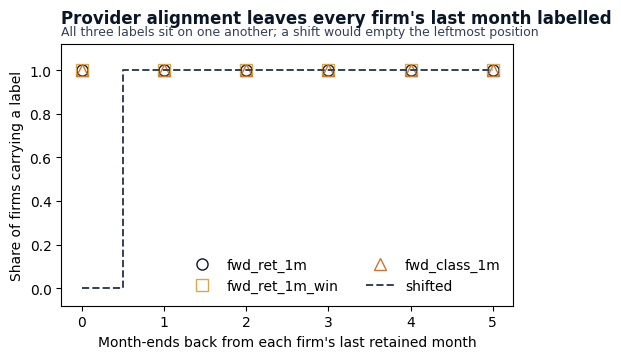

In [8]:
profile = (
    labels_df.with_columns(
        (pl.len().over("symbol") - 1 - pl.int_range(pl.len()).over("symbol")).alias("from_end"),
        pl.col(PRIMARY_LABEL).shift(-HORIZON_MONTHS).over("symbol").alias("_shifted"),
    )
    .filter(pl.col("from_end") <= HORIZON_MONTHS + 4)
    .group_by("from_end")
    .agg(pl.col(c).is_not_null().mean() for c in [*LABEL_NAMES, "_shifted"])
    .sort("from_end")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
back = profile["from_end"]
markers = zip(LABEL_NAMES, (COLORS["blue"], COLORS["amber"], COLORS["copper"]), "os^", strict=True)
for name, color, marker in markers:
    ax.plot(back, profile[name], marker, ms=8, mfc="none", c=color, label=name)
ax.plot(
    back, profile["_shifted"], "--", ds="steps-mid", lw=1.4, c=COLORS["neutral"], label="shifted"
)
ax.set(
    xlabel="Month-ends back from each firm's last retained month",
    ylabel="Share of firms carrying a label",
    ylim=(-0.08, 1.12),
)
add_message_title(
    ax,
    "Provider alignment leaves every firm's last month labelled",
    subtitle="All three labels sit on one another; a shift would empty the leftmost position",
)
ax.legend(loc="lower right", frameon=False, ncol=2)
show_with_alt(fig, "Non-null label rate by month-ends back from each firm's last observation.")

## E. Distribution and base rate

What scale is the label, and does it mean the same thing across regimes? The label files
keep every row, because the seal governs what this notebook looks at rather than what it
writes.

Both continuous labels go on one axis with identical bins and a logarithmic count axis.
The claim the figure has to support is about shape rather than width - two dispersion
scalars would carry the width - and the shape here is that the two series are
indistinguishable through the body and separate only in the tails, where the winsorized
label stops at the widest boundary any month produced and the raw one runs on. The axis is
narrower than the raw label's range, so the rows past it are counted below rather than
drawn. Those boundaries reach past one-and-a-half times the anchor price in the widest
month, so a tighter axis would cut the figure off exactly where the two labels separate.

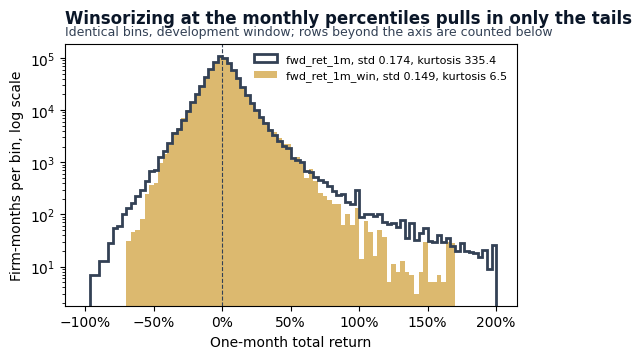

fwd_ret_1m: mean +0.01095, std 0.17430, kurtosis 335.36, range -0.961 to 18.997, 254 rows beyond the axis
fwd_ret_1m_win: mean +0.00878, std 0.14850, kurtosis 6.47, range -0.697 to 1.669, 0 rows beyond the axis


In [9]:
bins = np.linspace(-1.0, 2.0, 91)
histograms = {
    PRIMARY_LABEL: dict(color=COLORS["neutral"], histtype="step", lw=2, zorder=2),
    WINSORIZED_LABEL: dict(color=COLORS["amber"], alpha=0.8, zorder=1),
}
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name, style in histograms.items():
    series = dev[name]
    tag = f"{name}, std {series.std():.3f}, kurtosis {series.kurtosis():.1f}"
    ax.hist(series.to_numpy(), bins=bins, label=tag, **style)
ax.axvline(0, color=COLORS["neutral"], linestyle="--", lw=0.8)
ax.set(xlabel="One-month total return", ylabel="Firm-months per bin, log scale", yscale="log")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
add_message_title(
    ax,
    "Winsorizing at the monthly percentiles pulls in only the tails",
    subtitle="Identical bins, development window; rows beyond the axis are counted below",
)
ax.legend(loc="upper right", frameon=False, fontsize=8)
show_with_alt(fig, "Histograms of the raw and winsorized labels on identical bins, log counts.")

for name in (PRIMARY_LABEL, WINSORIZED_LABEL):
    series, drawn = dev[name], dev[name].is_between(bins[0], bins[-1]).sum()
    print(
        f"{name}: mean {series.mean():+.5f}, std {series.std():.5f}, "
        f"kurtosis {series.kurtosis():.2f}, range {series.min():.3f} to {series.max():.3f}, "
        f"{series.len() - drawn:,} rows beyond the axis"
    )

Chapter 7.2 asks for the scale and the base rate to be tracked through time. For the
continuous labels the quantity that has to hold up is the spread the model ranks within:
where it narrows, the same rank correlation buys less return. That spread is taken across
firms on each month-end first and only then averaged over the year, because pooling every
firm-month in a year into one standard deviation adds the market's own move from month to
month to the spread across firms, and a ranking model is scored on the second alone. For
the classification label the quantity is the share of firms in the upper class, and the
lower panel is what shows whether the median split delivered the balance it promises.

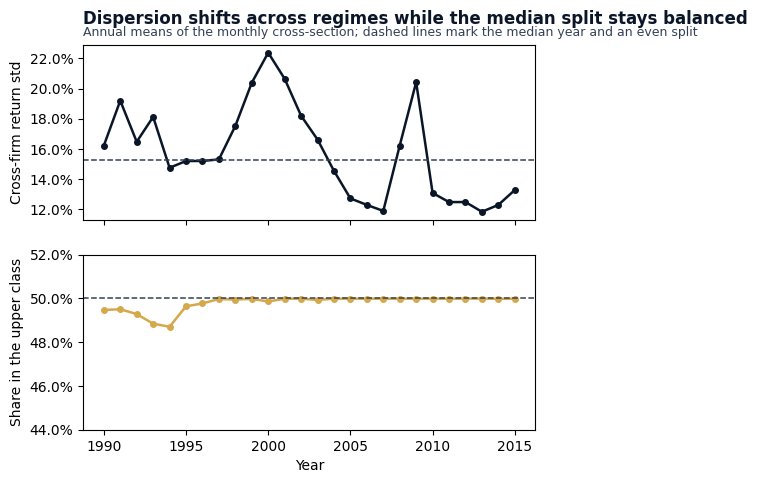

dispersion peaks at 22.4% in 2000 against 11.8% in 2013; median year 15.3%
upper class runs 0.438 to 0.500 per month, mean 0.498; the shortfall is returns tied at the median, up to 0.084 of a month's firms


In [10]:
monthly = dev.group_by("timestamp").agg(
    pl.col(PRIMARY_LABEL).std().alias("dispersion"),
    pl.col(CLASS_LABEL).mean().alias("upper_share"),
    (pl.col("ret") == pl.col("_median")).mean().alias("tied"),
)
annual = (
    monthly.group_by(pl.col("timestamp").dt.year().alias("year"))
    .agg(pl.col("dispersion").mean(), pl.col("upper_share").mean())
    .sort("year")
)
fig, axes = plt.subplots(2, 1, sharex=True, figsize=FIGSIZE["dual_v"])
panels = (
    ("dispersion", COLORS["blue"], annual["dispersion"].median(), "Cross-firm return std"),
    ("upper_share", COLORS["amber"], 0.5, "Share in the upper class"),
)
for ax, (column, color, reference, ylabel) in zip(axes, panels, strict=True):
    ax.plot(annual["year"], annual[column], "o-", ms=4, lw=1.8, c=color)
    ax.axhline(reference, color=COLORS["neutral"], ls="--", lw=1.1)
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set(ylim=(0.44, 0.52), xlabel="Year")
add_message_title(
    axes[0],
    "Dispersion shifts across regimes while the median split stays balanced",
    subtitle="Annual means of the monthly cross-section; dashed lines mark the median year "
    "and an even split",
)
show_with_alt(fig, "Annual mean cross-firm return dispersion above, upper-class share below.")

peak, trough = (annual.sort("dispersion", descending=d).row(0, named=True) for d in (True, False))
print(
    f"dispersion peaks at {peak['dispersion']:.1%} in {peak['year']:.0f} against "
    f"{trough['dispersion']:.1%} in {trough['year']:.0f}; median year "
    f"{annual['dispersion'].median():.1%}\n"
    f"upper class runs {monthly['upper_share'].min():.3f} to {monthly['upper_share'].max():.3f} "
    f"per month, mean {monthly['upper_share'].mean():.3f}; the shortfall is returns tied at the "
    f"median, up to {monthly['tied'].max():.3f} of a month's firms"
)

On the development window the raw label has a standard deviation of 0.17430 and a kurtosis
of 335.36, against 0.14850 and 6.47 for the winsorized variant: clipping at each month's
own percentiles touches a fiftieth of the rows and removes almost all of the fourth moment.
Cross-firm dispersion is not stable, peaking at 22.4% in 2000 against 11.8% in 2013 and a
median year of 15.3%, while the classification base rate is, running from 0.438 to 0.500 a
month around a mean of 0.498. The shortfall below an even split is returns tied at the
month's median, which reach 0.084 of the firms in a month.

## F. Overlap and effective sample size

A label sampled more often than its own horizon makes consecutive rows share part of one
forward window, and the row count then overstates the evidence. Here the sampling grid and
the horizon are the same month, so consecutive labels are built from disjoint returns. Two
measurements say so in different units: the autocorrelation profile, and the row count once
average uniqueness is priced in.

Both count on `month`, each row's position on the panel's own month-end grid, rather than
on position among the rows that survive into the development frame. Closing over the months
a firm skips would pair windows that share nothing.

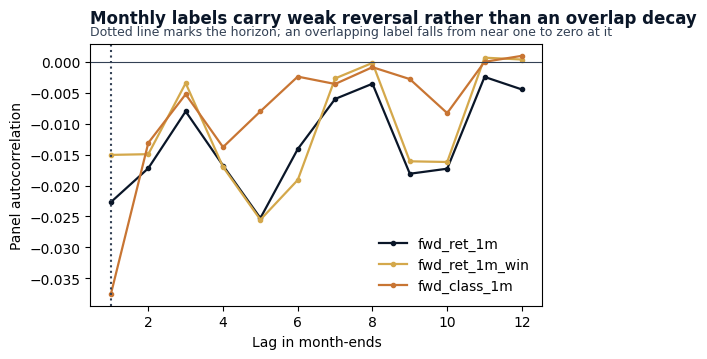

fwd_ret_1m: N=780,882, N_eff=780,882, ratio 1.0000; autocorrelation -0.0227 at lag one, -0.0045 at lag 12


In [11]:
MAX_LAG = 12
acf = {n: panel_autocorrelation(dev, n, max_lag=MAX_LAG, bar_col="month") for n in LABEL_NAMES}

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
lags = np.arange(1, MAX_LAG + 1)
palette = (COLORS["blue"], COLORS["amber"], COLORS["copper"])
for name, color in zip(LABEL_NAMES, palette, strict=True):
    ax.plot(lags, acf[name], "o-", ms=3, lw=1.6, c=color, label=name)
ax.axhline(0, color=COLORS["neutral"], lw=0.8)
ax.axvline(HORIZON_MONTHS, color=COLORS["neutral"], ls=":", lw=1.5)
ax.set(xlabel="Lag in month-ends", ylabel="Panel autocorrelation")
add_message_title(
    ax,
    "Monthly labels carry weak reversal rather than an overlap decay",
    subtitle="Dotted line marks the horizon; an overlapping label falls from near one to zero at it",
)
ax.legend(loc="lower right", frameon=False)
show_with_alt(fig, "Panel autocorrelation of all three labels against lag in month-ends.")

# A horizon-h label consumes the h returns realised over its window and its neighbour one
# period later shares h-1 of them, so at a one-period horizon nothing is shared at all.
n_rows, n_eff = effective_sample_size(dev, horizon=HORIZON_MONTHS, bar_col="month")
assert n_eff == n_rows, "a one-month label overlaps nothing, so every row must weigh one"
print(
    f"{PRIMARY_LABEL}: N={n_rows:,}, N_eff={n_eff:,.0f}, ratio {n_eff / n_rows:.4f}; "
    f"autocorrelation {acf[PRIMARY_LABEL][0]:+.4f} at lag one, "
    f"{acf[PRIMARY_LABEL][-1]:+.4f} at lag {MAX_LAG}"
)

The development window's 780,882 firm-months carry 780,882 effective observations: a
one-month label sampled monthly shares no return interval with its neighbour, so average
uniqueness is one and the ratio is 1.0000. What autocorrelation remains is the return
process rather than the label construction - -0.0227 at one month and -0.0045 at twelve -
and it is the short-term reversal `ST_REV` already carries as a characteristic. The purge
gap a fold needs is set by the forward window, which is one month here.

## G. Baseline floor

One signal against the primary label on the sealed development window, with no feature
engineering: the raw momentum characteristic `setup.yaml` names as the treatment its causal
stage estimates, taken exactly as the provider ranked it. Measuring the floor before
building features is what makes a later improvement meaningful.

The information coefficient is the cross-sectional rank correlation on each month-end,
averaged over month-ends, which is the quantity a ranking model is scored on; pooling every
firm-month instead mixes a cross-sectional claim with a time-series one. The library call
returns its series ordered by time, which the standard error depends on. The minimum
cross-section is half the median month, so it means the same thing on a universe of another
size. The standard error is HAC-adjusted, which here widens an interval that a monthly
series of one-month outcomes was already close to independent over.

In [12]:
baseline = dev.drop_nulls([BASELINE_SIGNAL, PRIMARY_LABEL])
min_obs = int(baseline.group_by("timestamp").len()["len"].median() // 2)

ic = cross_sectional_ic_series(
    baseline,
    baseline,
    pred_col=BASELINE_SIGNAL,
    ret_col=PRIMARY_LABEL,
    date_col="timestamp",
    entity_col="symbol",
    min_obs=min_obs,
).sort("timestamp")  # HAC autocovariances are meaningless over a permutation of time
stats = compute_ic_hac_stats(ic, ic_col="ic", label_horizon=HORIZON_MONTHS)

print(
    f"Baseline: {BASELINE_SIGNAL} against {PRIMARY_LABEL}, minimum cross-section {min_obs} firms\n"
    f"  month-ends scored {ic.height:,} of {dev['timestamp'].n_unique()}\n"
    f"  mean IC {stats['mean_ic']:+.5f}, HAC standard error {stats['hac_se']:.5f}\n"
    f"  HAC t {stats['t_stat']:+.2f} on {stats['effective_lags']} Bartlett lags, "
    f"naive t {stats['naive_t_stat']:+.2f}, p {stats['p_value']:.3g}"
)

Baseline: r12_2 against fwd_ret_1m, minimum cross-section 1293 firms
  month-ends scored 312 of 312
  mean IC +0.04398, HAC standard error 0.00716
  HAC t +6.14 on 5 Bartlett lags, naive t +6.89, p 2.53e-09


Raw momentum earns a mean information coefficient of +0.04398 against the monthly label
over all 312 development month-ends, on a cross-section of at least 1293 firms. Under the
naive standard error that is a t-statistic of +6.89; the Newey-West rule picks 5 lags here,
above the none a one-month horizon requires on its own, and the HAC statistic is +6.14 with
a standard error of 0.00716. The floor a feature has to clear is therefore not zero: it is
a mean IC of 0.04398 that the data separates clearly from zero, before any feature exists.

## H. Artifacts and the audit record

Each file is written with a digest sidecar beside it, recording the content digest of the
values written, the row count, the key columns, the notebook that wrote it and the digests
of what it was built from. That last field is what ties a label to its data vintage. The
characteristic panel goes out first, because the backtest loader prices this case study's
positions from it and all three labels derive from its `ret` column; the two variants
additionally carry the primary label's digest, which is what they transform.

In [13]:
prices = write_artifact(
    firm_chars.select([*KEYS, "ret", *CHARACTERISTICS]),
    LABELS_DIR / "prices.parquet",
    keys=KEYS,
    written_by="02_labels",
    inputs={"market_data": MARKET_DATA_DIGEST},
)
print(f"prices.parquet: {prices['n_rows']:,} rows, digest {prices['digest']}")

records: dict[str, dict] = {}
for name in LABEL_NAMES:
    derived = {} if name == PRIMARY_LABEL else {PRIMARY_LABEL: records[PRIMARY_LABEL]["digest"]}
    records[name] = write_artifact(
        labels_df.select([*KEYS, name]).drop_nulls(),
        LABELS_DIR / f"{name}.parquet",
        keys=KEYS,
        written_by="02_labels",
        inputs={"prices": prices["digest"], **derived},
    )
    print(f"{name}.parquet: {records[name]['n_rows']:,} rows, digest {records[name]['digest']}")

prices.parquet: 804,530 rows, digest abd84a4d7ac9efb9
fwd_ret_1m.parquet: 804,530 rows, digest bdef9bbf157ac5dc
fwd_ret_1m_win.parquet: 804,530 rows, digest 12683a54d5d2ffe2
fwd_class_1m.parquet: 804,530 rows, digest f51353e988d0c4f9


The folds that train models are derived per label by `case_studies/utils/cv_window.py` from
`config/setup.yaml` and the timeline of the label parquet written above, so which rows land
in these files is what sets where the fold boundaries fall. The same generator writes them
to `config/cv_config.json`, which `04_evaluation.py` reads to score its feature ICs fold by
fold.

In [14]:
splits = generate_cv_splits(
    labels_df.select("timestamp"),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
    outcome_horizon=HORIZON,
)
assert len(splits) == int(SETUP["evaluation"]["n_splits"])
assert max(split["val_end"] for split in splits).date() < HOLDOUT_START

BLOCKS = ("train_start", "train_end", "val_start", "val_end")
cv_config = {
    "case_study_id": CASE_STUDY_ID,
    "n_splits": len(splits),
    "train_size": str(SETUP["evaluation"]["train_size"]),
    "val_size": str(SETUP["evaluation"]["val_size"]),
    "holdout_start": HOLDOUT_START.isoformat(),
    "holdout_end": str(SETUP["evaluation"]["holdout_end"]),
    "splits": [
        {"fold": int(split["fold"]), "label_buffer": LABEL_BUFFER}
        | {key: split[key].date().isoformat() for key in BLOCKS}
        for split in splits
    ],
}
cv_path = CASE_DIR / "config" / "cv_config.json"
cv_path.write_text(json.dumps(cv_config, indent=2) + "\n")
last_val = max(split["val_end"] for split in splits).date()
print(f"Saved {display_path(cv_path)}: {len(splits)} folds, validation through {last_val}")

Saved case_studies/us_firm_characteristics/config/cv_config.json: 10 folds, validation through 2015-11-30


The record Chapter 7.2 requires to close a label definition, one row per label, built from
the values computed above rather than written by hand.

In [15]:
readers = {PRIMARY_LABEL: "03_financial_features.py, which joins it into the trainable panel"}
print("\nLabel audit record")
for name in LABEL_NAMES:
    series = dev[name]
    base_rate = (
        f"upper class {series.mean():.3f} of firms"
        if name == CLASS_LABEL
        else f"mean {series.mean():+.5f}, std {series.std():.5f}"
    )
    print(
        f"\n{name}\n  anchor       adjusted month-end close of the month before the row's"
        f"\n  horizon      {HORIZON}, the month the row is dated by"
        f"\n  resolution   fixed at that month's close; monthly bars need no intraday tie-break"
        f"\n  overlap      {HORIZON_MONTHS - 1} months shared by consecutive rows"
        f"\n  base rate    {base_rate}"
        f"\n  consumed by  {readers.get(name, 'the model stages, through config/training/')}"
    )


Label audit record

fwd_ret_1m
  anchor       adjusted month-end close of the month before the row's
  horizon      1M, the month the row is dated by
  resolution   fixed at that month's close; monthly bars need no intraday tie-break
  overlap      0 months shared by consecutive rows
  base rate    mean +0.01095, std 0.17430
  consumed by  03_financial_features.py, which joins it into the trainable panel

fwd_ret_1m_win
  anchor       adjusted month-end close of the month before the row's
  horizon      1M, the month the row is dated by
  resolution   fixed at that month's close; monthly bars need no intraday tie-break
  overlap      0 months shared by consecutive rows
  base rate    mean +0.00878, std 0.14850
  consumed by  the model stages, through config/training/

fwd_class_1m
  anchor       adjusted month-end close of the month before the row's
  horizon      1M, the month the row is dated by
  resolution   fixed at that month's close; monthly bars need no intraday tie-break
  ov

## Key takeaways

1. **Read a pre-built panel's alignment out of the data before relying on it.** A
   characteristic that restates a past return, correlated against the label at each
   candidate lag, says which row's outcome the characteristics were recorded before - and
   shifting a panel that was already shifted fails silently.
2. **Assert that a label exists exactly where its outcome was observed.** A count of valid
   rows reports a fabricated tail and a complete one identically; the null rate read
   against each entity's own last period separates them.
3. **A threshold taken across the cross-section needs no fold scoping; one taken along
   time does.** A month's own median and percentiles use only information that month
   already carries, so they can be applied to every row of the sample at once.
4. **A row count only overstates the evidence when forward windows overlap.** Sampling a
   label at its own horizon leaves average uniqueness at one, which an effective count has
   to return exactly - and that is the case which catches an off-by-one inside it.
5. **Set the floor with the signal the design names, not the strongest one available.**
   The number a later feature has to beat is only meaningful if it was fixed before the
   features existed.

**Known limitations.** The release is anonymized and its firm axis persists only inside
each published block, so nothing here reconciles against a named security or a
corporate-action record. The provider computes the return, so its conventions for delisting
and dividend reinvestment are inherited rather than checked. The baseline is one
characteristic of the several dozen the release carries.

**Next**: `03_financial_features.py` builds fundamental, momentum and cross-sectional rank
features from these characteristics and evaluates them against these labels.